In [ ]:
# install dependencies (run for the first time only)
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

## **`Data cleaning`**

In [ ]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [ ]:
# load data
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

url = r'https://raw.githubusercontent.com/dhieu0901/DSEB65A_MachineLearningProject_Group5/refs/heads/main/data/Hanoi%20Daily%2010%20years.csv'

df = pd.read_csv(url)

print("Data size (Rows, Columns):", df.shape)
print(df.head())

Data size (Rows, Columns): (3660, 33)
    name   datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0  Hanoi  9/20/2015     33.0     26.7  29.3          41.7          30.5   
1  Hanoi  9/21/2015     29.5     25.0  26.8          34.4          25.0   
2  Hanoi  9/22/2015     28.5     25.0  25.9          32.8          25.0   
3  Hanoi  9/23/2015     31.3     25.5  28.0          39.7          25.5   
4  Hanoi  9/24/2015     34.5     26.5  29.9          43.5          26.5   

   feelslike   dew  humidity  ...  solarenergy  uvindex  severerisk  \
0       35.4  25.7      81.5  ...         12.2        5         NaN   
1       29.2  24.3      86.3  ...          5.8        3         NaN   
2       26.5  24.2      90.5  ...          7.2        3         NaN   
3       32.0  25.4      86.2  ...         12.1        5         NaN   
4       36.4  25.9      80.4  ...         19.5        8         NaN   

               sunrise               sunset  moonphase  \
0  2015-09-20T05:44:39  20

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3660 non-null   object 
 1   datetime          3660 non-null   object 
 2   tempmax           3660 non-null   float64
 3   tempmin           3660 non-null   float64
 4   temp              3660 non-null   float64
 5   feelslikemax      3660 non-null   float64
 6   feelslikemin      3660 non-null   float64
 7   feelslike         3660 non-null   float64
 8   dew               3660 non-null   float64
 9   humidity          3660 non-null   float64
 10  precip            3660 non-null   float64
 11  precipprob        3660 non-null   int64  
 12  precipcover       3660 non-null   float64
 13  preciptype        2673 non-null   object 
 14  snow              3660 non-null   int64  
 15  snowdepth         3660 non-null   int64  
 16  windgust          3660 non-null   float64


In [ ]:
df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,...,3660.000000,3660.000000,3660.000000,3660.00000,3660.000000,3660.000000,3660.000000,3660.000000,1000.0000,3660.000000
mean,28.460519,21.882814,24.844426,32.541011,22.636202,27.320355,20.432158,78.259235,5.231195,71.912568,...,17.284863,126.427678,1011.188934,64.42776,8.616721,154.137568,13.304672,5.816940,29.2560,0.484781
std,5.810885,4.857733,5.111883,9.518917,6.047288,7.712572,5.841853,10.907329,16.031570,44.948764,...,4.953989,97.777963,7.142358,23.11523,1.738703,76.573769,6.618988,2.463028,24.4205,0.288801
min,8.000000,5.900000,7.000000,8.000000,2.100000,4.600000,-2.000000,31.000000,0.000000,0.000000,...,6.500000,0.000000,991.100000,0.00000,2.600000,0.000000,0.000000,0.000000,5.0000,0.000000
25%,24.100000,18.000000,21.000000,24.100000,18.000000,21.000000,16.700000,72.100000,0.000000,0.000000,...,13.900000,60.375000,1005.300000,50.67500,7.700000,90.875000,7.800000,4.000000,10.0000,0.250000
50%,29.400000,23.000000,26.000000,32.700000,23.000000,26.900000,22.400000,79.900000,0.217500,100.000000,...,16.600000,108.950000,1010.950000,67.50000,9.000000,152.750000,13.200000,6.000000,10.0000,0.500000
75%,33.000000,26.000000,28.900000,41.100000,26.000000,33.800000,25.200000,85.900000,2.500000,100.000000,...,20.500000,131.800000,1016.700000,82.10000,9.800000,214.925000,18.600000,8.000000,60.0000,0.750000
max,41.900000,31.000000,35.500000,52.500000,40.400000,46.200000,28.500000,100.000000,333.117000,100.000000,...,53.600000,359.800000,1037.200000,100.00000,12.600000,323.500000,27.900000,10.000000,100.0000,0.980000


In [ ]:
df[:5]

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Hanoi,9/20/2015,33.0,26.7,29.3,41.7,30.5,35.4,25.7,81.5,...,12.2,5,NaN,2015-09-20T05:44:39,2015-09-20T17:55:33,0.23,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,"48820099999,48823099999,48825099999,4883109999..."
1,Hanoi,9/21/2015,29.5,25.0,26.8,34.4,25.0,29.2,24.3,86.3,...,5.8,3,NaN,2015-09-21T05:44:54,2015-09-21T17:54:36,0.25,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"48820099999,48823099999,48825099999,4883109999..."
2,Hanoi,9/22/2015,28.5,25.0,25.9,32.8,25.0,26.5,24.2,90.5,...,7.2,3,NaN,2015-09-22T05:45:08,2015-09-22T17:53:39,0.30,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"48820099999,48823099999,48825099999,4883109999..."
3,Hanoi,9/23/2015,31.3,25.5,28.0,39.7,25.5,32.0,25.4,86.2,...,12.1,5,NaN,2015-09-23T05:45:23,2015-09-23T17:52:42,0.33,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"48820099999,48823099999,48825099999,4883109999..."
4,Hanoi,9/24/2015,34.5,26.5,29.9,43.5,26.5,36.4,25.9,80.4,...,19.5,8,NaN,2015-09-24T05:45:38,2015-09-24T17:51:45,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,"48820099999,48823099999,48825099999,4883109999..."


## **`Handling missing values for time-series problem`**

In [ ]:
# initial data shape
# please check this carefully as we would modify it later
df.shape

(3660, 33)

In [ ]:
# handling Missing Values

def check_missing_values(df):
    """Return missing percentage for each column."""
    missing = df.isnull().mean() * 100
    return missing[missing > 0].sort_values(ascending=False)

missing_ratio = check_missing_values(df)
print("\nMissing Value Ratio (%):")
print(missing_ratio)

# focus on specific columns
if 'severerisk' in df.columns:
    print(f"\nsevererisk missing: {missing_ratio['severerisk']:.2f}%")
if 'preciptype' in df.columns:
    print(f"preciptype missing: {missing_ratio['preciptype']:.2f}%")


Missing Value Ratio (%):
severerisk    72.677596
preciptype    26.967213
dtype: float64

severerisk missing: 72.68%
preciptype missing: 26.97%


## **`Dropping redundant and zero-variance cols`**

In [ ]:
# Constant and Zero-Variance Columns

def find_constant_columns(df):
    """Find columns with only one unique (non-null) value."""
    # This also finds numeric columns with zero variance
    return [col for col in df.columns if df[col].nunique(dropna=True) <= 1]

# find all constant columns
constant_cols = find_constant_columns(df)
print("\nConstant or Zero-Variance Columns Detected:")
print(constant_cols)

# (domain knowledge) other potential cols that should be dropped for future refactor
other_cols_to_drop = ['address', 'resolvedAddress', 'source', 'latitude', 'longitude', 'severerisk', 'stations']

# combine the lists and remove duplicates -> use set
all_cols_to_drop = list(set(constant_cols + other_cols_to_drop))

print("\nFull list of columns to be dropped:")
print(all_cols_to_drop)

# 4. drop the columns that actually exist in the dataframe
# PLEASE note that from now on we only process with cleaned_df for better later debugging
cleaned_df = df.drop(columns=[c for c in all_cols_to_drop if c in df.columns], errors='ignore')


Constant or Zero-Variance Columns Detected:
['name', 'preciptype', 'snow', 'snowdepth']

Full list of columns to be dropped:
['preciptype', 'snow', 'name', 'latitude', 'longitude', 'severerisk', 'source', 'stations', 'resolvedAddress', 'snowdepth', 'address']


In [ ]:
# check the date shape
print("\nDataset shape after dropping redundant columns:")
print("Before:", df.shape, "-> After:", cleaned_df.shape)


Dataset shape after dropping redundant columns:
Before: (3660, 33) -> After: (3660, 27)


In [ ]:
# call check_missing_values() again for validation
remaining_missing = check_missing_values(cleaned_df)
if(remaining_missing.empty):
    print("\nNo more missing values")
else:
    print("\nRemaining Missing Value Ratio (%):")
    print(remaining_missing)


No more missing values


## **`Correcting Data Types`**

##### **Converting to timestamp datatype for time-series analysis**

In [ ]:
# convert to timestamp data type
cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
cleaned_df['sunrise'] = pd.to_datetime(cleaned_df['sunrise'])
cleaned_df['sunset'] = pd.to_datetime(cleaned_df['sunset'])

##### **Multi-label Columns processing**  

**Cols**: `conditions`, `description`.

##### **Problem**:
|   | conditions           |
|---|----------------------|
| 0 | Rain, Partially cloudy |
| 1 | Rain, Overcast        |
| 2 | Rain, Overcast        |
| 3 | Rain, Partially cloudy |
| 4 | Rain, Partially cloudy |

```python
df['description'][0], df['conditions'][0]
>> ('Partly cloudy throughout the day with late afternoon rain.', 'Rain, Partially cloudy')
```

- `df['conditions']` does not contain a single category, but rather a string with multiple values separated by commas.

- For example: `'Rain, Partially cloudy'` means the day had both `Rain` **AND** `Partially cloudy` weather conditions.

- Additionally, the `description` column provides a textual summary of conditions column. For example, the description `'Partly cloudy throughout the day with late afternoon rain.'` corresponds to the conditions `'Rain, Partially cloudy'`.

##### **Solution:**

1. Use **Multi-Label Binarization**. This technique converts each individual label within a multi-label string into a separate binary column, enabling the model to interpret each label independently rather than as a combined entity. In pandas, the simplest and most effective approach is to use the `str.get_dummies()` method.
2. Drop `df['description']`.


In [ ]:
df['description'][0], df['conditions'][0]

('Partly cloudy throughout the day with late afternoon rain.',
 'Rain, Partially cloudy')

In [ ]:
# multi-label cols processing
# split 'condition' col into binary cols (sep=',')
conditions_dummies = cleaned_df['conditions'].str.get_dummies(sep=', ')

# concat to the processing dataframe
cleaned_df = pd.concat([cleaned_df, conditions_dummies], axis=1)

# now the original
cleaned_df.drop('conditions', axis=1, inplace=True)

# we can and must also drop df['description'],
# because it is just the more complicated version of df['condition'] which we have already handled
cleaned_df.drop('description', axis=1, inplace=True)

##### **One-hot Encoding**

The `icon` column is of object type and needs to be transformed into a numeric format for machine learning models. To do this, we apply **One-Hot Encoding**, a technique that converts categorical data into binary vectors.

This transformation ensures the model can process the data numerically and treat each icon category as a separate feature.


In [ ]:
# apply one-hot encoding
icon_dummies = pd.get_dummies(cleaned_df['icon'], prefix='icon')

# concat
cleaned_df = pd.concat([cleaned_df, icon_dummies], axis=1)

# drop orignal one
cleaned_df.drop('icon', axis=1, inplace=True)

## **`Main: Feature Engineering`**

##### **General Philosophy**
Our goal is to create new columns (features) that answer questions the model might "ask" in order to predict the temperature. For example:

*"Was it hot or cold yesterday?"* -> **Lag Features**

*"Did the temperature trend upward last week?"* -> **Rolling Features**

*"What season is it now?"* -> **Time-based Features**

*"Is the perceived temperature much different from the actual temperature?"* -> **Interaction Features**


In [ ]:
"""
##### **main things to do in this section:**
###### feature extraction:
1. date/time decomposition
4. holiday/season indicators (binary)
2. lag features
3. rolling window stats
6. seasonal decomposition
8. interaction terms
9. external regressors + auto regressive features
###### feature transformation:
5. cyclical encoding (sin/cos)
7. fourier transformation (seasonality)
"""

### **feature extraction**

1. **`date/time decomposition`**

In [ ]:
# ADJUSTED

# Các thành phần thời gian cơ bản (Decomposition)
cleaned_df['month'] = cleaned_df['datetime'].dt.month
cleaned_df['day_of_year'] = cleaned_df['datetime'].dt.dayofyear
cleaned_df['day_of_week'] = cleaned_df['datetime'].dt.dayofweek
cleaned_df['week_of_year'] = cleaned_df['datetime'].dt.isocalendar().week.astype(int)
cleaned_df['year'] = cleaned_df['datetime'].dt.year
cleaned_df['quarter'] = cleaned_df['datetime'].dt.quarter  # quarter
cleaned_df['day_of_month'] = cleaned_df['datetime'].dt.day  # day of month
cleaned_df['is_weekend'] = cleaned_df['day_of_week'].isin([5, 6]).astype(int)  # binary

# Daylight duration (Domain-specific decomposition)
cleaned_df['daylight_duration_sec'] = (cleaned_df['sunset'] - cleaned_df['sunrise']).dt.total_seconds()
cleaned_df['daylight_duration_sec'].fillna(0, inplace=True)  # handle NaN

# Feature mùa và mã hóa one-hot (Season Indicators)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
cleaned_df['season'] = cleaned_df['month'].apply(get_season)
season_dummies = pd.get_dummies(cleaned_df['season'], prefix='season')
cleaned_df = pd.concat([cleaned_df, season_dummies], axis=1)

/tmp/ipython-input-1302143445.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df['daylight_duration_sec'].fillna(0, inplace=True)  # handle NaN


2. **`holidays/seasons indicators`**

In [ ]:
# NEW

import holidays

# Thêm holiday indicators (Binary cho holiday)
# cho nay dung holidays.VN de trich xuat cac ngay le o vn
vn_holidays = holidays.VN(years=range(cleaned_df['year'].min(), cleaned_df['year'].max() + 1))
cleaned_df['is_holiday'] = cleaned_df['datetime'].apply(lambda x: 1 if x in vn_holidays else 0)

In [ ]:
# # DRAFT

# # Mã hóa cyclical cho các biến thời gian
# cleaned_df['month_sin'] = np.sin(2 * np.pi * cleaned_df['month'] / 12)
# cleaned_df['month_cos'] = np.cos(2 * np.pi * cleaned_df['month'] / 12)
# cleaned_df['day_of_year_sin'] = np.sin(2 * np.pi * cleaned_df['day_of_year'] / 365.25)
# cleaned_df['day_of_year_cos'] = np.cos(2 * np.pi * cleaned_df['day_of_year'] / 365.25)

# # Mã hóa cyclical cho các biến thời gian (Số 5)
# cleaned_df['month_sin'] = np.sin(2 * np.pi * cleaned_df['month'] / 12)
# cleaned_df['month_cos'] = np.cos(2 * np.pi * cleaned_df['month'] / 12)
# cleaned_df['day_of_year_sin'] = np.sin(2 * np.pi * cleaned_df['day_of_year'] / 365.25)
# cleaned_df['day_of_year_cos'] = np.cos(2 * np.pi * cleaned_df['day_of_year'] / 365.25)
# cleaned_df['day_of_week_sin'] = np.sin(2 * np.pi * cleaned_df['day_of_week'] / 7)  # Thêm cho hàng tuần
# cleaned_df['day_of_week_cos'] = np.cos(2 * np.pi * cleaned_df['day_of_week'] / 7)

#### 5. **`seasonal decomposition`**

Phân rã chuỗi thời gian bằng phương pháp STL (Seasonal-Trend decomposition using Loess) là một kỹ thuật thống kê mạnh mẽ được sử dụng để tách dữ liệu chuỗi thời gian thành ba thành phần chính: **`Xu hướng (Trend)`**, **`Tính mùa vụ (Seasonality)`**, và **`Phần dư (Residual)`**.
```python
Observed = Trend + Seasonal + Residual
```

##### **Ý tưởng**: dùng ACF và PACF để kiểm tra tính tự tương quan (autocorrelation) của phần dư (residuals).
**ACF (Autocorrelation Function)** và **PACF (Partial Autocorrelation Function)** là hai công cụ quan trọng trong phân tích chuỗi thời gian, giúp ta hiểu mối quan hệ giữa các giá trị trong chuỗi tại các thời điểm khác nhau.

---

##### **1. ACF (Autocorrelation Function)**

ACF đo lường mức độ tương quan giữa giá trị của chuỗi tại thời điểm hiện tại với giá trị của chuỗi tại các thời điểm trước đó (lag). Nó giúp ta hiểu xem một giá trị trong chuỗi có liên quan như thế nào với các giá trị trong quá khứ.

- **ACF formulas**:
  $$
  \rho_k = \frac{\text{Cov}(X_t, X_{t-k})}{\sqrt{\text{Var}(X_t) \cdot \text{Var}(X_{t-k})}}
  $$
  - $\rho_k$: Tương quan tự động tại độ trễ $k$.
  - $X_t$: Giá trị chuỗi tại thời điểm $t$.
  - $\text{Cov}(X_t, X_{t-k})$: Hiệp phương sai giữa giá trị tại thời điểm $t$ và $t-k$.
  - $\text{Var}(X_t)$: Phương sai của chuỗi tại thời điểm $t$.
  
**Áp dụng**
- Áp dung ACF trên phần dư (residuals) để kiểm tra xem phần dư có còn chứa các mẫu tự tương quan (patterns) hay không. Nếu phần dư có tự tương quan đáng kể, điều này cho thấy STL chưa loại bỏ hết các mẫu thời gian -> cần điều chỉnh mô hình hoặc thêm feature.

---

##### **2. PACF (Partial Autocorrelation Function)**

PACF đo lường mức độ tương quan giữa giá trị chuỗi tại thời điểm hiện tại với giá trị tại một thời điểm trước đó, nhưng sau khi loại bỏ ảnh hưởng của các giá trị ở các độ trễ thấp hơn. Nó giúp xác định độ trễ thực sự có ảnh hưởng trực tiếp đến giá trị hiện tại.

- **PACF formulas**:
  $$
  \phi_{kk} = \text{Corr}(X_t - \hat{X}_t, X_{t-k} - \hat{X}_{t-k})
  $$
  Trong đó $\hat{X}_t$ và $\hat{X}_{t-k}$ là các ước lượng tuyến tính dựa trên các biến trung gian $X_{t-1}, \dots, X_{t-k+1}$.
  - $\phi_{kk}$: Tương quan riêng phần tại độ trễ $k$.
  
**Áp dụng**
- Sau khi STL, phần dư (residuals) lý tưởng nên là *white noise* (ngẫu nhiên, không có tự tương quan). Nếu ACF/PACF cho thấy các đỉnh vượt qua ngưỡng tin cậy (confidence interval, thường là ±1.96/√n), thì phần dư vẫn chứa các mẫu thời gian -> cần cải thiện feature engineering hoặc mô hình.

---

##### **Tóm lại**

- **ACF** đo lường mối tương quan **tổng thể** (cả trực tiếp và gián tiếp) giữa các giá trị chuỗi ở các độ trễ khác nhau.
- **PACF** đo lường mối tương quan **trực tiếp** sau khi đã loại bỏ ảnh hưởng của các độ trễ trung gian.

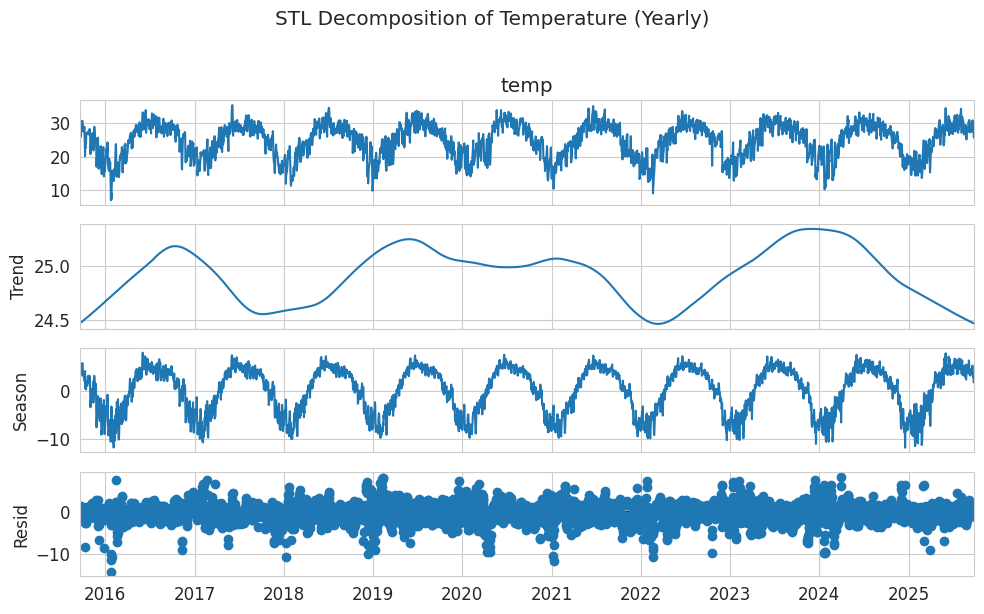

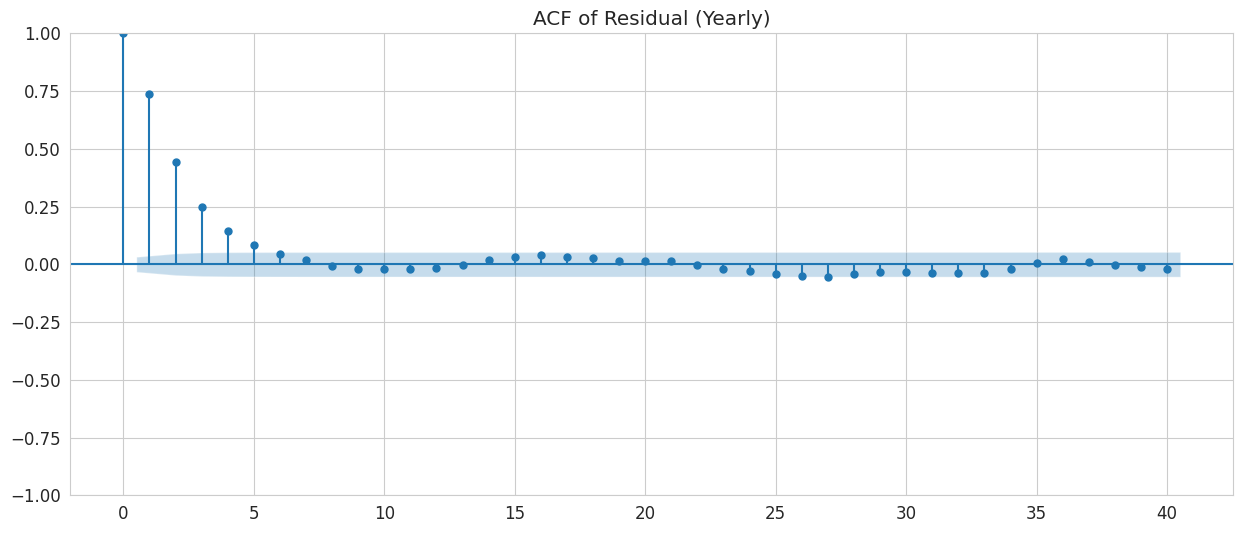

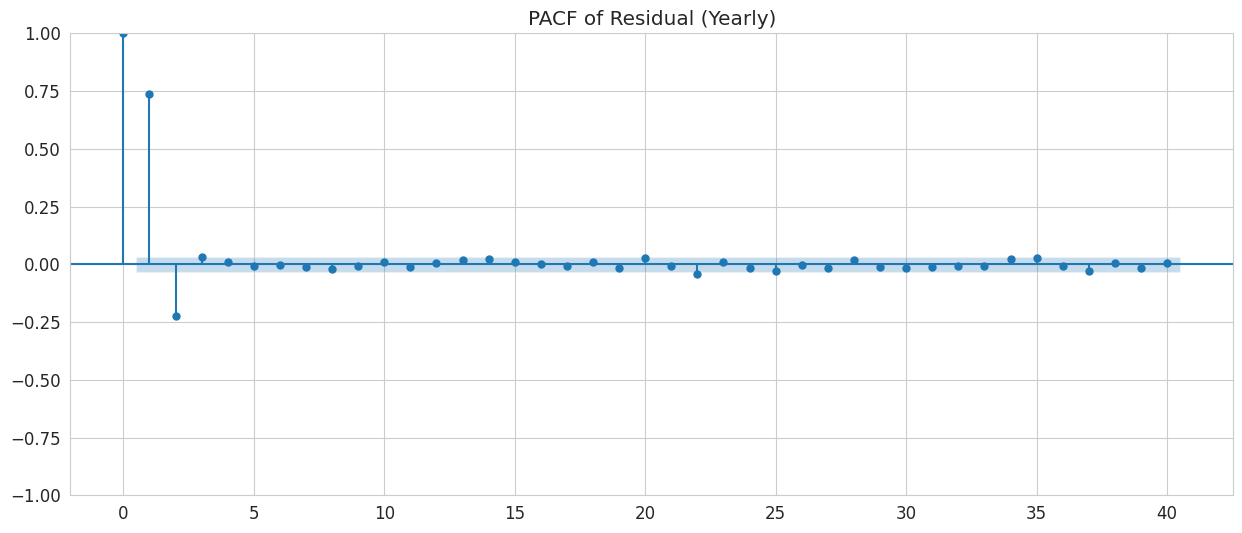

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Để check resid

# Đảm bảo index là datetime và sorted (tích hợp từ code mới)
if 'datetime' in cleaned_df.columns:
    cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
    cleaned_df.set_index('datetime', inplace=True)
cleaned_df.sort_index(inplace=True)  # sort

# Chọn target, handle NaN ban đầu
series_to_decompose = cleaned_df['temp'].dropna()  # Hoặc fill nếu cần: .fillna(method='ffill')

# STL yearly
stl_yearly = STL(series_to_decompose, period=365, seasonal=13, robust=True)
result_yearly = stl_yearly.fit()

# Visualization yearly
fig = result_yearly.plot()
fig.set_size_inches(10, 6)
plt.suptitle('STL Decomposition of Temperature (Yearly)', y=1.02)
plt.tight_layout()
plt.show()

# Check resid autocorrelation
plot_acf(result_yearly.resid.dropna(), lags=40, title='ACF of Residual (Yearly)')
plt.show()

plot_pacf(result_yearly.resid.dropna(), lags=40, title='PACF of Residual (Yearly)')
plt.show()

##### **concat vào dataset**

In [ ]:
# Thêm features vào dataset
cleaned_df['temp_trend_yearly'] = result_yearly.trend
cleaned_df['temp_seasonal_yearly'] = result_yearly.seasonal
cleaned_df['temp_resid_yearly'] = result_yearly.resid

In [ ]:
# Handle NaN sau decomposition
print("NaN in new features before handling:")
print(cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].isna().sum())

if cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].isna().any().any():
    # Forward/backward fill để giữ tính liên tục time series
    cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']] = \
        cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].fillna(method='ffill')
    cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']] = \
        cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].fillna(method='bfill')

print("NaN after handling:", cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].isna().sum().sum())

# Kiểm tra head
print(cleaned_df[['temp', 'temp_seasonal_yearly', 'temp_trend_yearly', 'temp_resid_yearly']].head())

NaN in new features before handling:
temp_trend_yearly       0
temp_seasonal_yearly    0
temp_resid_yearly       0
dtype: int64
NaN after handling: 0
            temp  temp_seasonal_yearly  temp_trend_yearly  temp_resid_yearly
datetime                                                                    
2015-09-20  29.3              4.610702          24.467468           0.221830
2015-09-21  26.8              3.172797          24.469298          -0.842094
2015-09-22  25.9              3.111623          24.471129          -1.682752
2015-09-23  28.0              3.536615          24.472963          -0.009578
2015-09-24  29.9              4.256419          24.474799           1.168782


##### **Nhận xét**

###### **STL decomposition plot (yearly)**

- **Dữ liệu gốc (temp - Observed)**:
  - Chuỗi dữ liệu nhiệt độ ban đầu.
  - Chu kỳ lên xuống rõ rệt, đỉnh vào mùa hè và thấp vào mùa đông.

- **Xu hướng (Trend)**:
  - Thể hiện xu hướng dài hạn sau khi loại bỏ biến động mùa vụ.
  - Nhiệt độ tăng nhẹ từ 2016 đến 2019-2020, sau đó giảm và tăng trở lại.
  - Có thể phản ánh các chu kỳ khí hậu dài hạn hoặc xu hướng nóng lên toàn cầu.

- **Thành phần Mùa vụ (Seasonal)**:
  - Tách biệt chu kỳ hàng năm rõ ràng.
  - Mô hình thay đổi nhiệt độ giữa các mùa, biên độ dao động khoảng +/- 10°C so với xu hướng.

- **Phần dư (Residual)**:
  - Phần dư dao động quanh 0 với biên độ nhỏ (khoảng ±5), cho thấy STL đã tách tốt xu hướng và mùa vụ. Tuy nhiên, vẫn có một số điểm nhiễu đáng kể, cần kiểm tra thêm bằng ACF/PACF.
  - Một số điểm outliers lớn, thể hiện nhiệt độ bất thường (ví dụ: đợt lạnh đột ngột) không thể giải thích bằng xu hướng hoặc chu kỳ mùa vụ.


###### **Biểu Đồ ACF of Residual (Yearly)**
**Quan sát:**
* Có đỉnh rất cao tại lag 0 (tự tương quan hoàn hảo, điều này là bình thường).
* Tại lag 1, ACF giảm mạnh nhưng vẫn vượt ngưỡng tin cậy (confidence interval, các đường chấm xanh lam), cho thấy tự tương quan đáng kể giữa giá trị hiện tại và giá trị ngày trước đó.
* Các lag sau (2, 3, v.v.) giảm dần, nhưng một số lag (như 365) có thể có tự tương quan nhẹ (khó xác định chính xác do biểu đồ bị cắt).

**Ý nghĩa:**
* Phần dư (residual) vẫn chứa tự tương quan ngắn hạn (lag 1), cho thấy nhiệt độ ngày hôm nay vẫn còn phụ thuộc vào ngày hôm qua, một yếu tố mà phép phân rã STL chưa loại bỏ hoàn toàn.
* Điều này gợi ý rằng có thể cần thêm các feature trễ (lag features) hoặc kiểm tra các chu kỳ mùa vụ ngắn hơn (ví dụ: hàng tuần hoặc hàng tháng).

---

###### **PACF of Residual (Yearly)**
**Quan sát:**
* Đỉnh rất cao tại lag 0 (bình thường).
* Tại lag 1, PACF có giá trị rất đáng kể (vượt ngưỡng tin cậy), sau đó giảm mạnh và dao động quanh 0 ở các lag tiếp theo.
* Không có mẫu hình rõ ràng ở các lag lớn hơn, cho thấy ảnh hưởng trực tiếp chủ yếu đến từ lag 1.

**Ý nghĩa:**
* Phần dư có thể được mô hình hóa tốt bởi một quá trình **AR(1)** (AutoRegressive bậc 1), vì biểu đồ PACF "cắt đứt" (cuts off) một cách rõ rệt sau lag 1.
* Điều này xác nhận rằng phần dư phụ thuộc trực tiếp vào giá trị ngay trước đó (lag 1), và STL chưa loại bỏ hết tính tự tương quan ngắn hạn này.

---

##### **Kết Luận**
* Phép phân rã **STL đã tách tốt xu hướng dài hạn và mùa vụ hàng năm**, nhưng phần dư còn lại vẫn chứa **sự tương quan ngắn hạn** (chủ yếu ở lag 1).
* Nguyên nhân có thể là do:
    * Tần suất của dữ liệu (hàng ngày) có chứa các mẫu hình mà STL với chu kỳ `period=365` không xử lý hết được.
    * Mô hình hiện tại thiếu các feature trễ hoặc các chu kỳ mùa vụ ngắn hạn khác.
* Phần dư **không phải là nhiễu trắng (white noise)**, cho thấy vẫn còn thông tin có thể khai thác. Cần cải thiện mô hình bằng cách **bổ sung các feature** hoặc sử dụng một mô hình lai (hybrid model) kết hợp STL với một mô hình khác (như ARIMA) để xử lý phần dư.

### **Derived Features**

#### 3. **`lag features`**

In [ ]:
# ADJUSTED

# Lag features
lag_cols = ['temp', 'humidity', 'windspeed', 'cloudcover', 'precip']
lags = [1, 2, 7, 30, 365]

for col in lag_cols:
    for lag in lags:
        cleaned_df[f'{col}_lag_{lag}'] = cleaned_df[col].shift(lag)
    cleaned_df[f'{col}_diff_1'] = cleaned_df[col].diff(periods=1)
    cleaned_df[f'{col}_diff_7'] = cleaned_df[col].diff(periods=7)


#### 4. **`rolling window stast`**

In [ ]:
# NEW
from statsmodels.tsa.stattools import pacf

# Rolling: Mở rộng cho tất cả lag_cols, thêm EWMA
windows = [3, 7, 14, 30]
for col in lag_cols:
    for window in windows:
        # Rolling trên past data (shift(1) để tránh leakage)
        shifted = cleaned_df[col].shift(1)
        cleaned_df[f'{col}_roll_mean_{window}'] = shifted.rolling(window=window, min_periods=1).mean()
        cleaned_df[f'{col}_roll_std_{window}'] = shifted.rolling(window=window, min_periods=1).std()

        # Thêm min/max/sum cho các cột phù hợp
        if col in ['temp', 'precip', 'windspeed']:
            cleaned_df[f'{col}_roll_min_{window}'] = shifted.rolling(window=window, min_periods=1).min()
            cleaned_df[f'{col}_roll_max_{window}'] = shifted.rolling(window=window, min_periods=1).max()
        if col == 'precip':
            cleaned_df[f'{col}_roll_sum_{window}'] = shifted.rolling(window=window, min_periods=1).sum()

# EWMA
for col in lag_cols:
    cleaned_df[f'{col}_ewm_7'] = cleaned_df[col].shift(1).ewm(span=7, adjust=False).mean()
    cleaned_df[f'{col}_ewm_30'] = cleaned_df[col].shift(1).ewm(span=30, adjust=False).mean()

/tmp/ipython-input-1971019402.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_df[f'{col}_roll_mean_{window}'] = shifted.rolling(window=window, min_periods=1).mean()
/tmp/ipython-input-1971019402.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_df[f'{col}_roll_std_{window}'] = shifted.rolling(window=window, min_periods=1).std()
/tmp/ipython-input-1971019402.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

#### **xử lý lags**

In [ ]:
# Chỉ giữ lại các lags có PACF vượt CI ±1.96/√n
from statsmodels.tsa.stattools import pacf

# Hàm chọn lags dựa trên PACF
def select_lags_based_on_pacf(series, max_lags=365, threshold=None):  # Tăng max_lags
    series_clean = series.dropna()
    if threshold is None and len(series_clean) > 0:
        threshold = 1.96 / np.sqrt(len(series_clean))
    pacf_values = pacf(series_clean, nlags=max_lags, alpha=None)
    significant_lags = [lag for lag in range(1, len(pacf_values)) if abs(pacf_values[lag]) > threshold]
    return significant_lags[:5] if len(significant_lags) > 5 else significant_lags

# Áp dụng PACF
initial_lags = [1, 2, 7, 30, 365]
selected_lags = {}
discarded_lags = {}

for col in lag_cols:
    series = cleaned_df[col]
    lags = select_lags_based_on_pacf(series)
    selected_lags[col] = lags
    discarded_lags[col] = [lag for lag in initial_lags if lag not in lags]
    print(f"\nColumn: {col}")
    print(f"Significant lags kept: {selected_lags[col]}")
    print(f"Discarded lags: {discarded_lags[col]}")

# Tạo lại lag features
cleaned_df_adjusted = cleaned_df.copy()
for col in lag_cols:
    current_cols = [c for c in cleaned_df.columns if c.startswith(f'{col}_lag_')]
    cleaned_df_adjusted.drop(columns=current_cols, inplace=True)
    if selected_lags[col]:
        for lag in selected_lags[col]:
            cleaned_df_adjusted[f'{col}_lag_{lag}'] = cleaned_df[col].shift(lag)
    else:
        print(f"No significant lags for {col}, keeping original column.")


Column: temp
Significant lags kept: [1, 2, 3, 4, 5]
Discarded lags: [7, 30, 365]

Column: humidity
Significant lags kept: [1, 2, 3, 4, 9]
Discarded lags: [7, 30, 365]

Column: windspeed
Significant lags kept: [1, 3, 7, 8, 9]
Discarded lags: [2, 30, 365]

Column: cloudcover
Significant lags kept: [1, 2, 3, 4, 6]
Discarded lags: [7, 30, 365]

Column: precip
Significant lags kept: [1, 2, 3, 4, 5]
Discarded lags: [7, 30, 365]


##### **=>Ở đây có nhận xét rằng có vẻ đã đi đúng hướng vì bước trên chỉ ra residual vẫn còn chứa tương quan ngắn hạn.**

In [ ]:
# Xử lý NaN
cleaned_df_adjusted.fillna(method='bfill', inplace=True)  # Chọn bfill hoặc ffill

# Gán lại dữ liệu
cleaned_df = cleaned_df_adjusted

/tmp/ipython-input-541126571.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df_adjusted.fillna(method='bfill', inplace=True)  # Chọn bfill hoặc ffill


#### 6. **`feature Interactions`**

### 1. Hiệu ứng của nhiệt độ 1 ngày trước trong mùa hè

- **Feature mới:** `interaction_lag1_summer`
- **Công thức:** Bằng `temp_lag_1` nếu `season_Summer` là 1. Bằng 0 nếu là các mùa khác.
- **Mục đích:** Giúp mô hình hiểu được ảnh hưởng riêng biệt của nhiệt độ ngày hôm trước trong mùa hè.

---

### 2. Hiệu ứng của nhiệt độ 1 ngày trước vào cuối tuần

- **Feature mới:** `interaction_lag1_weekend`
- **Công thức:** Bằng `temp_lag_1` nếu `is_weekend` là 1. Bằng 0 nếu là các ngày trong tuần.
- **Mục đích:** Đo lường sự khác biệt trong ảnh hưởng của nhiệt độ ngày hôm trước giữa cuối tuần và ngày thường.

---

### 3. Tương tác giữa các Feature Thời tiết ("Hiệu ứng gió lạnh")

- **Feature mới:** `interaction_wind_clearsky_effect`
- **Công thức:** `windspeed * (1 - cloudcover / 100.0)`
- **Giả thuyết:** Tác động của gió lạnh sẽ mạnh mẽ hơn khi trời quang đãng, ảnh hưởng đến nhiệt độ cảm nhận.

---

### 4. Bức xạ hiệu dụng (Effective Solar Radiation)

- **Feature mới:** `effective_radiation`
- **Công thức:** `solarradiation * (1 - cloudcover / 100.0)`
- **Giả thuyết:** Lượng bức xạ mặt trời thực tế tới mặt đất giảm đi khi trời có nhiều mây. Feature này giúp mô hình dự báo nhiệt độ hiệu quả hơn.

---

### 5. Tương tác giữa Độ ẩm và Nhiệt độ

- **Feature mới:** `humidity_temp_interact`
- **Công thức:** `humidity * temp`
- **Giả thuyết:** Có thể đại diện cho các chỉ số như "nhiệt độ cảm nhận" (heat index) hoặc "điểm sương" (dew point), giúp mô hình hiểu rằng ảnh hưởng của độ ẩm thay đổi tùy theo nhiệt độ.

In [ ]:
# NEW

# Hiệu ứng của nhiệt độ 1 ngày trước trong mùa hè
cleaned_df['interaction_lag1_summer'] = cleaned_df['temp_lag_1'] * cleaned_df['season_Summer']

# Hiệu ứng của nhiệt độ 1 ngày trước vào cuối tuần
cleaned_df['interaction_lag1_weekend'] = cleaned_df['temp_lag_1'] * cleaned_df['is_weekend']

# "Hiệu ứng gió lạnh" = tốc độ gió * (mức độ quang đãng của bầu trời)
cleaned_df['interaction_wind_clearsky_effect'] = cleaned_df['windspeed'] * (1 - cleaned_df['cloudcover'] / 100.0)

# Bức xạ hiệu dụng (Effective Solar Radiation)
cleaned_df['effective_radiation'] = cleaned_df['solarradiation'] * (1 - cleaned_df['cloudcover'] / 100)

# Tương tác giữa Độ ẩm và Nhiệt độ
cleaned_df['humidity_temp_interact'] = cleaned_df['humidity'] * cleaned_df['temp']

In [ ]:
# Validation
columns_to_show = [
    'temp_lag_1', 'season_Summer', 'interaction_lag1_summer',  # Thay temp_lag_7 bằng temp_lag_1
    'is_weekend', 'interaction_lag1_weekend',  # Thay temp_lag_7 bằng temp_lag_1
    'windspeed', 'cloudcover', 'interaction_wind_clearsky_effect'
]
print(cleaned_df[columns_to_show].head(10))

# In ra danh sách các cột cuối cùng
print("\nCác cột cuối cùng trong DataFrame:")
print(cleaned_df.columns[-5:])

            temp_lag_1  season_Summer  interaction_lag1_summer  is_weekend  \
datetime                                                                     
2015-09-20        29.3          False                      0.0           1   
2015-09-21        29.3          False                      0.0           0   
2015-09-22        26.8          False                      0.0           0   
2015-09-23        25.9          False                      0.0           0   
2015-09-24        28.0          False                      0.0           0   
2015-09-25        29.9          False                      0.0           0   
2015-09-26        30.5          False                      0.0           1   
2015-09-27        28.6          False                      0.0           1   
2015-09-28        29.6          False                      0.0           0   
2015-09-29        30.3          False                      0.0           0   

            interaction_lag1_weekend  windspeed  cloudcover  \


#### 6. **`domain-specific features`**

In [ ]:
# Biên độ nhiệt trong ngày
cleaned_df['temp_range'] = cleaned_df['tempmax'] - cleaned_df['tempmin']

# Độ bão hòa hơi nước
cleaned_df['dew_point_depression'] = cleaned_df['temp'] - cleaned_df['dew']

### **`Feature transformation`**

#### 1. **`cyclical encoding`**

##### **Cyclical Encoding**

###### Nguyên Tắc:
Biến chu kỳ (cyclic variable) được biểu diễn bằng hai chiều: **sin** và **cos**. Các giá trị này dao động từ -1 đến 1, phản ánh vị trí trong chu kỳ.

---

###### Công Thức:
``` r
sin_value = sin(2 * pi * value / max_period)
cos_value = cos(2 * pi * value / max_period)
```
Trong đó:
* `value`: Giá trị của biến chu kỳ (ví dụ: giờ, ngày).
* `max_period`: Chu kỳ lớn nhất của biến (ví dụ: 24 cho giờ, 7 cho ngày trong tuần, 365 cho ngày trong năm).

###### Áp dụng:
Phù hợp với các biến như `hour_of_day`, `day_of_week`, `day_of_year`, `month_of_year`.

In [ ]:
# NEW
# cyclical encoding
cleaned_df['day_of_year'] = cleaned_df.index.dayofyear
cleaned_df['sin_day_of_year'] = np.sin(2 * np.pi * cleaned_df['day_of_year'] / 365)
cleaned_df['cos_day_of_year'] = np.cos(2 * np.pi * cleaned_df['day_of_year'] / 365)

# same to hour_of_day
if cleaned_df.index.freq == 'H' or cleaned_df.index.freq == 'h':
    cleaned_df['hour_of_day'] = cleaned_df.index.hour
    cleaned_df['sin_hour_of_day'] = np.sin(2 * np.pi * cleaned_df['hour_of_day'] / 24)
    cleaned_df['cos_hour_of_day'] = np.cos(2 * np.pi * cleaned_df['hour_of_day'] / 24)

# Xử lý NaN
cleaned_df.fillna(method='bfill', inplace=True)
cleaned_df.fillna(method='ffill', inplace=True)

/tmp/ipython-input-1082448005.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='bfill', inplace=True)
/tmp/ipython-input-1082448005.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='ffill', inplace=True)


In [ ]:
# Mã hóa hướng gió (0-360 độ)
cleaned_df['winddir_sin'] = np.sin(np.deg2rad(cleaned_df['winddir']))
cleaned_df['winddir_cos'] = np.cos(np.deg2rad(cleaned_df['winddir']))

# Mã hóa pha mặt trăng (0-1)
cleaned_df['moonphase_sin'] = np.sin(2 * np.pi * cleaned_df['moonphase'])
cleaned_df['moonphase_cos'] = np.cos(2 * np.pi * cleaned_df['moonphase'])

#### 2. **`Vector transformation`**

In [ ]:
# Vector gió (sử dụng các cột sin/cos đã tạo)
cleaned_df['wind_vector_ns'] = cleaned_df['windspeed'] * cleaned_df['winddir_cos']
cleaned_df['wind_vector_ew'] = cleaned_df['windspeed'] * cleaned_df['winddir_sin']

#### 3. **`Fourier transformation`**

Top frequencies: [-0.01530055  0.01229508 -0.01229508]
Chu kỳ tương ứng: [-65.35714286  81.33333333 -81.33333333]


/tmp/ipython-input-1367053316.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='bfill', inplace=True)
/tmp/ipython-input-1367053316.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='ffill', inplace=True)


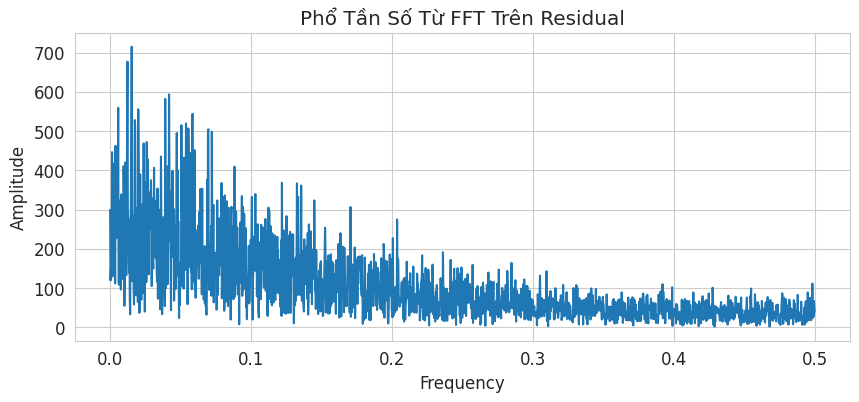

            fft_sin_freq_1  fft_cos_freq_1  fft_sin_freq_2  fft_cos_freq_2  \
datetime                                                                     
2015-09-20       -0.000000        1.000000        0.000000        1.000000   
2015-09-21       -0.095988        0.995382        0.077175        0.997018   
2015-09-22       -0.191090        0.981573        0.153891        0.988088   
2015-09-23       -0.284427        0.958698        0.229688        0.973264   
2015-09-24       -0.375137        0.926969        0.304115        0.952635   
2015-09-25       -0.462383        0.886680        0.376728        0.926324   
2015-09-26       -0.545359        0.838203        0.447094        0.894487   
2015-09-27       -0.623298        0.781984        0.514793        0.857315   
2015-09-28       -0.695481        0.718544        0.579421        0.815028   
2015-09-29       -0.761242        0.648468        0.640593        0.767880   

            fft_sin_freq_3  fft_cos_freq_3  
datetime          

In [ ]:
from scipy.fft import fft, fftfreq  # Thêm cho FFT

residual = result_yearly.resid.dropna().values  # Residual từ STL
n = len(residual)  # Độ dài chuỗi

# Tính FFT trên residual
fft_values = fft(residual)
frequencies = fftfreq(n)

# Lấy biên độ và chọn top 3 tần số (bỏ freq=0)
amplitudes = np.abs(fft_values)
top_freq_indices = np.argsort(amplitudes)[::-1][1:4]  # Top 3
top_frequencies = frequencies[top_freq_indices]

# Tạo feature sin/cos từ top frequencies
t = np.arange(n)  # Thời gian index
for i, freq in enumerate(top_frequencies):
    cleaned_df[f'fft_sin_freq_{i+1}'] = np.sin(2 * np.pi * freq * t)
    cleaned_df[f'fft_cos_freq_{i+1}'] = np.cos(2 * np.pi * freq * t)

# Xử lý NaN nếu có
cleaned_df.fillna(method='bfill', inplace=True)
cleaned_df.fillna(method='ffill', inplace=True)

# Kiểm tra kết quả
print("Top frequencies:", top_frequencies)
print("Chu kỳ tương ứng:", 1 / top_frequencies[top_frequencies != 0])

# Vẽ phổ tần số (tùy chọn)
plt.figure(figsize=(10, 4))
plt.plot(frequencies[:n//2], amplitudes[:n//2])
plt.title('Phổ Tần Số Từ FFT Trên Residual')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()

# In head của feature mới
new_columns = [col for col in cleaned_df.columns if 'fft' in col]
print(cleaned_df[new_columns].head(10))

In [ ]:
# check features
cleaned_df.columns.to_list()

['tempmax',
 'tempmin',
 'temp',
 'feelslikemax',
 'feelslikemin',
 'feelslike',
 'dew',
 'humidity',
 'precip',
 'precipprob',
 'precipcover',
 'windgust',
 'windspeed',
 'winddir',
 'sealevelpressure',
 'cloudcover',
 'visibility',
 'solarradiation',
 'solarenergy',
 'uvindex',
 'sunrise',
 'sunset',
 'moonphase',
 'Clear',
 'Overcast',
 'Partially cloudy',
 'Rain',
 'icon_clear-day',
 'icon_cloudy',
 'icon_partly-cloudy-day',
 'icon_rain',
 'month',
 'day_of_year',
 'day_of_week',
 'week_of_year',
 'year',
 'quarter',
 'day_of_month',
 'is_weekend',
 'daylight_duration_sec',
 'season',
 'season_Fall',
 'season_Spring',
 'season_Summer',
 'season_Winter',
 'is_holiday',
 'temp_trend_yearly',
 'temp_seasonal_yearly',
 'temp_resid_yearly',
 'temp_diff_1',
 'temp_diff_7',
 'humidity_diff_1',
 'humidity_diff_7',
 'windspeed_diff_1',
 'windspeed_diff_7',
 'cloudcover_diff_1',
 'cloudcover_diff_7',
 'precip_diff_1',
 'precip_diff_7',
 'temp_roll_mean_3',
 'temp_roll_std_3',
 'temp_roll_min

In [ ]:
# Danh sách các cột gốc cần xóa vì thông tin đã được chuyển hóa
cols_to_drop = [
    'datetime', 'sunrise', 'sunset', # Đã khai thác
    'winddir', 'moonphase',         # Đã mã hóa
    'season',                       # Đã mã hóa one-hot
    'name', 'stations', 'description', 'preciptype', 'icon', 'conditions', # Cột không cần thiết
    'severerisk', # Có quá nhiều giá trị thiếu
    'feelslike',
    'feelslikemax',
    'feelslikemin',
]

# Chỉ xóa các cột thực sự tồn tại
existing_cols_to_drop = [col for col in cols_to_drop if col in cleaned_df.columns]
cleaned_df.drop(columns=existing_cols_to_drop, inplace=True)
print(f"   - Dropped {len(existing_cols_to_drop)} unnecessary columns.")

# Xóa tất cả các dòng có NaN (chủ yếu do lag và rolling)
initial_rows = len(cleaned_df)
cleaned_df.dropna(inplace=True)
final_rows = len(cleaned_df)
print(f"   - Dropped {initial_rows - final_rows} rows with NaN values.")


   - Dropped 8 unnecessary columns.
   - Dropped 0 rows with NaN values.


In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3660 entries, 2015-09-20 to 2025-09-26
Columns: 175 entries, tempmax to fft_cos_freq_3
dtypes: bool(8), float64(152), int32(6), int64(9)
memory usage: 4.6 MB


#### 76 features are...
-> Lets go do some correlation analysis

### **`Correlation analysis`**

In [ ]:
# Select numeric columns
num_df = cleaned_df.select_dtypes(include=[np.number])

# Compute Pearson correlation
corr_matrix = num_df.corr()

# Visualization function
def plot_correlation_heatmap(correlation_matrix, figsize=(20, 15), annot=False, title="Correlation Matrix"):
    """
    Vẽ heatmap tương quan. Mặc định tắt annot để dễ nhìn hơn với ma trận lớn.
    """
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    plt.figure(figsize=figsize)
    sns.heatmap(correlation_matrix,
                mask=mask,          # Luôn áp dụng mask
                cmap='coolwarm',
                center=0,
                annot=annot,        # Tùy chọn bật/tắt giá trị
                fmt=".2f",
                linewidths=.5)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# # call function
# plot_correlation_heatmap(corr_matrix, annot=False, title="Tổng Quan Tương Quan Giữa Các Feature")


In [ ]:
# Sort top correlations with temp
top_corr = corr_matrix['temp'].abs().sort_values(ascending=False).head(40)
print("\nTop 40 Features Correlated with 'temp':")
print(top_corr)


Top 40 Features Correlated with 'temp':
temp                       1.000000
tempmax                    0.977442
tempmin                    0.969415
temp_lag_1                 0.945100
temp_roll_min_3            0.911240
temp_roll_mean_3           0.905517
temp_ewm_7                 0.905007
dew                        0.903089
temp_seasonal_yearly       0.891597
temp_roll_max_3            0.881554
temp_roll_min_7            0.878219
temp_roll_mean_7           0.874797
temp_lag_2                 0.874399
sealevelpressure           0.867498
temp_roll_mean_14          0.865161
temp_roll_min_14           0.859489
humidity_temp_interact     0.857033
temp_ewm_30                0.853705
temp_roll_max_7            0.845163
temp_roll_mean_30          0.837413
temp_roll_max_14           0.833321
temp_lag_3                 0.825089
temp_roll_min_30           0.816328
cos_day_of_year            0.816123
temp_roll_max_30           0.810949
temp_lag_4                 0.795902
temp_lag_5             

In [ ]:
# Handling multicolinearity

def find_highly_correlated_features(corr_matrix, threshold=0.95):
    """
    Find feature pairs with correlation above the specified threshold.
    """
    # Get the upper triangle of the correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find feature pairs with correlation > threshold
    highly_correlated_pairs = [
        (column, upper_tri[column].abs().idxmax(), upper_tri[column].abs().max())
        for column in upper_tri.columns if upper_tri[column].abs().max() > threshold
    ]

    # Sort for easier viewing
    sorted_pairs = sorted(highly_correlated_pairs, key=lambda x: x[2], reverse=True)

    return sorted_pairs


def drop_correlated_features(df, correlated_pairs, target_col):
    """
    Drop one feature from each highly correlated pair.
    This function keeps the feature that has higher correlation with the target variable.
    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        correlated_pairs (list): List of highly correlated feature pairs from the find_highly_correlated_features function.
        target_col (str): The name of the target column (e.g., 'temp').
    Returns:
        pd.DataFrame: The new DataFrame with features dropped.
        set: A set of dropped columns.
    """
    cols_to_drop = set()

    # Calculate correlation of all features with the target column once
    corr_with_target = df.corr()[target_col].abs()

    # Iterate through the pairs found
    for feat1, feat2, _ in correlated_pairs:
        # Get the correlation values with the target for each feature in the pair
        corr1 = corr_with_target.get(feat1, 0)
        corr2 = corr_with_target.get(feat2, 0)

        # Decide which feature to drop
        if corr1 > corr2:
            # Keep feat1, drop feat2
            cols_to_drop.add(feat2)
        else:
            # Keep feat2, drop feat1
            cols_to_drop.add(feat1)

    # Drop the identified columns
    df_reduced = df.drop(columns=list(cols_to_drop))

    print(f"\nDropped {len(cols_to_drop)} features due to multicollinearity.")
    if cols_to_drop:
        print("- Dropped columns:", list(cols_to_drop))

    return df_reduced, cols_to_drop

In [ ]:
# Find pairs with correlation > 0.95
correlated_pairs = find_highly_correlated_features(corr_matrix, threshold=0.95)

print("\n feature pairs with very high correlation (> 0.95):")
for feat1, feat2, corr_val in correlated_pairs:
    print(f"- {feat1:<25} and {feat2:<25} : {corr_val:.4f}")

df_final, dropped_cols = drop_correlated_features(df=cleaned_df,
                                                  correlated_pairs=correlated_pairs,
                                                  target_col='temp')


 feature pairs with very high correlation (> 0.95):
- Rain                      and precipprob                : 1.0000
- fft_sin_freq_3            and fft_sin_freq_2            : 1.0000
- fft_cos_freq_3            and fft_cos_freq_2            : 1.0000
- precip_roll_sum_3         and precip_roll_mean_3        : 1.0000
- solarenergy               and solarradiation            : 0.9999
- precip_roll_sum_7         and precip_roll_mean_7        : 0.9998
- precip_roll_sum_14        and precip_roll_mean_14       : 0.9991
- precip_roll_sum_30        and precip_roll_mean_30       : 0.9975
- precip_roll_max_7         and precip_roll_std_7         : 0.9975
- day_of_year               and month                     : 0.9965
- temp_ewm_30               and temp_roll_mean_30         : 0.9949
- precip_roll_max_14        and precip_roll_std_14        : 0.9936
- precip_roll_max_3         and precip_roll_std_3         : 0.9921
- temp_ewm_7                and temp_roll_mean_7          : 0.9919
- dew_poi

In [ ]:
# Lấy top 20 features từ danh sách tương quan với target
top_20_features = top_corr.head(20).index

# Tạo ma trận tương quan mới chỉ với các feature này
small_corr_matrix = cleaned_df[top_20_features].corr()

Top 20 features sau khi đã loại bỏ đa cộng tuyến:
temp                       1.000000
tempmin                    0.969415
temp_lag_1                 0.945100
temp_ewm_7                 0.905007
dew                        0.903089
temp_seasonal_yearly       0.891597
temp_roll_min_7            0.878219
sealevelpressure           0.867498
temp_ewm_30                0.853705
cos_day_of_year            0.816123
season_Winter              0.719726
solarradiation             0.615518
interaction_lag1_summer    0.572874
season_Summer              0.564930
temp_roll_std_30           0.553945
precip_roll_mean_30        0.545764
precip_ewm_30              0.528621
precip_roll_std_30         0.518086
humidity_roll_std_30       0.507428
temp_roll_std_14           0.497976
Name: temp, dtype: float64


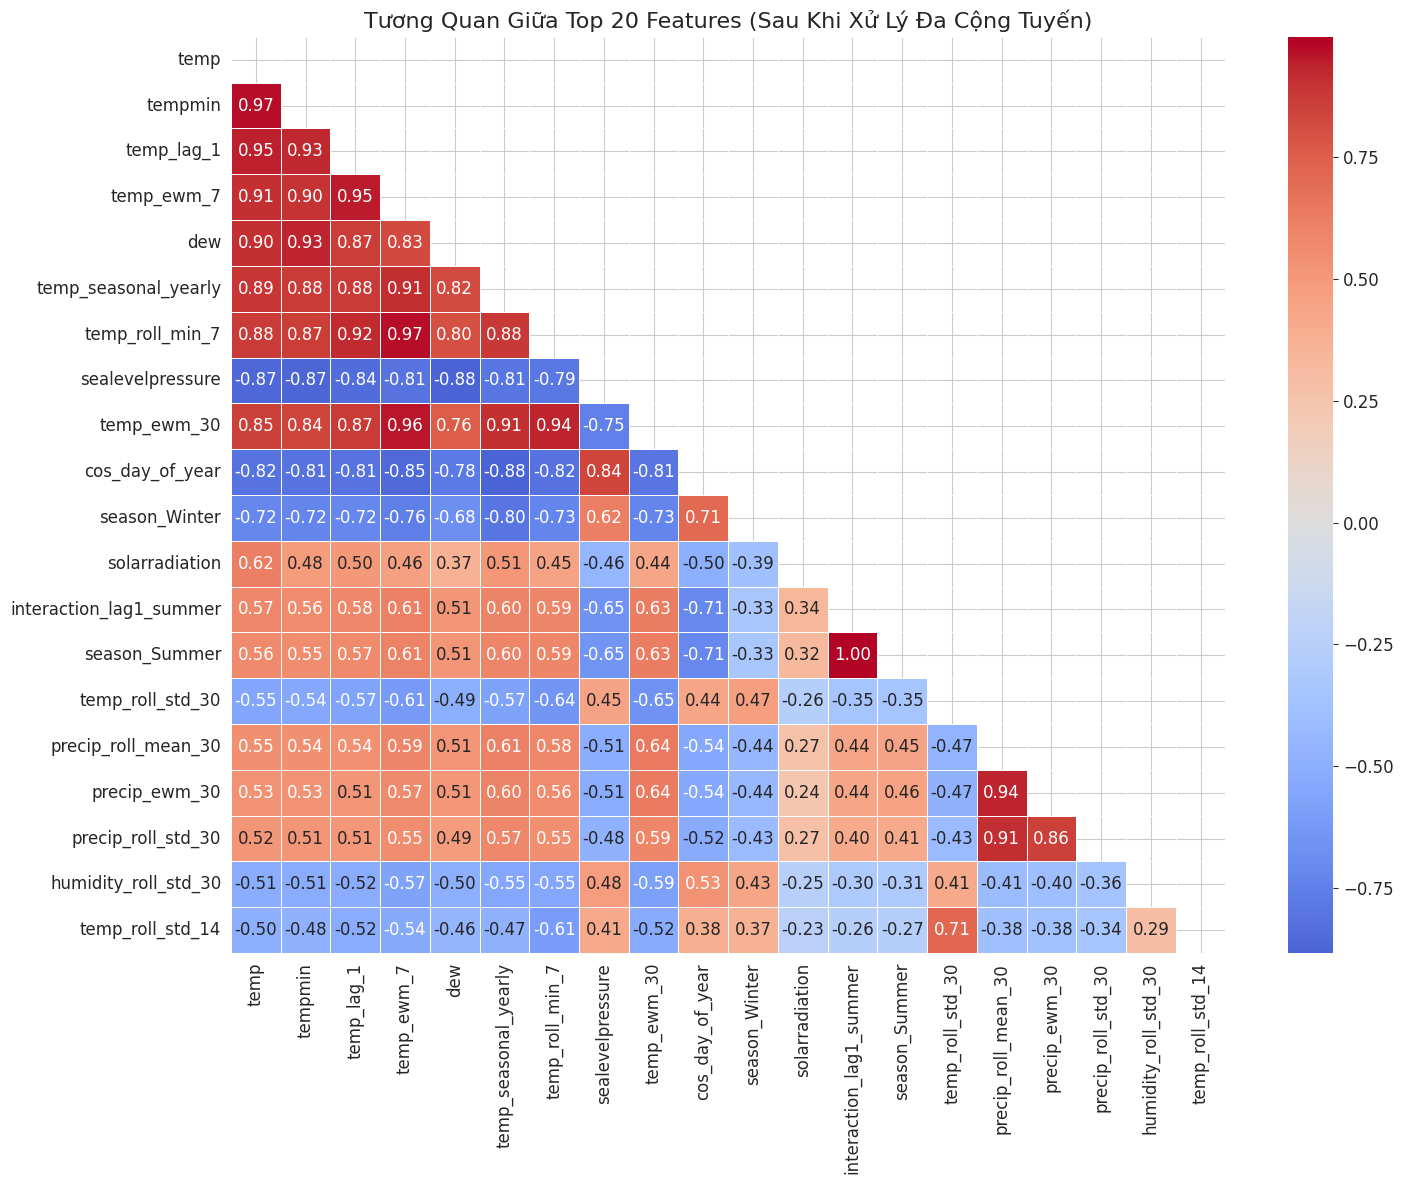

In [ ]:
# 1. Tính toán lại ma trận tương quan trên df_final
corr_matrix_final = df_final.corr()

# 2. Lấy chuỗi tương quan với cột 'temp' và sắp xếp
corr_with_target_final = corr_matrix_final['temp'].abs().sort_values(ascending=False)

# 3. In ra top 20 feature mạnh nhất còn lại
print("Top 20 features sau khi đã loại bỏ đa cộng tuyến:")
print(corr_with_target_final.head(20))

# 4. Lấy danh sách tên của top 20 feature
top_20_final_features = corr_with_target_final.head(20).index

# 5. Tạo ma trận tương quan mới chỉ với các feature này
small_corr_matrix_final = df_final[top_20_final_features].corr()

# 6. Vẽ heatmap chi tiết cuối cùng
plot_correlation_heatmap(
    small_corr_matrix_final,
    figsize=(15, 12),
    annot=True,
    title="Tương Quan Giữa Top 20 Features (Sau Khi Xử Lý Đa Cộng Tuyến)"
)

#### lam lai chia test theo form time-series

Top 30 features quan trọng nhất (tính trên tập train):
                              feature  importance
0                             tempmin    0.934847
122                        temp_range    0.038536
97                         temp_lag_1    0.009654
2                            humidity    0.002627
30                  temp_resid_yearly    0.002537
87                         temp_ewm_7    0.000866
31                        temp_diff_1    0.000776
11                     solarradiation    0.000596
121               effective_radiation    0.000477
29               temp_seasonal_yearly    0.000391
1                                 dew    0.000299
108                  cloudcover_lag_1    0.000268
8                    sealevelpressure    0.000261
32                        temp_diff_7    0.000232
9                          cloudcover    0.000202
43                    temp_roll_min_7    0.000183
88                        temp_ewm_30    0.000181
118           interaction_lag1_summer    0.00

/tmp/ipython-input-2168486309.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')


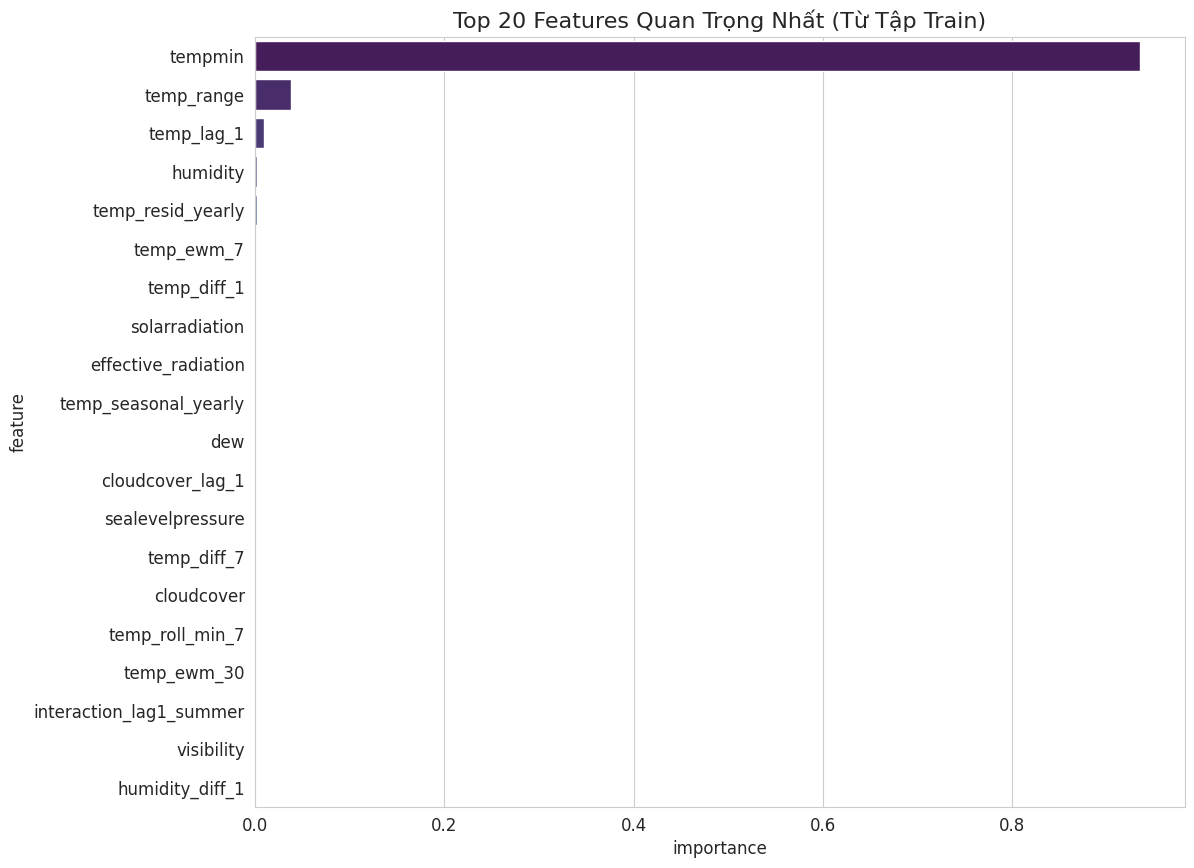


Shape mới của X_train: (2440, 30)
Shape mới của X_test: (1220, 30)


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Giả sử df_final đã sắp xếp theo thời gian
X = df_final.drop('temp', axis=1)
y = df_final['temp']

# Sử dụng TimeSeriesSplit với n_splits=2 để có một split train/test
tscv = TimeSeriesSplit(n_splits=2)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# 2. TÌM FEATURE IMPORTANCE CHỈ TRÊN TẬP TRAIN
model_for_selection = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_for_selection.fit(X_train, y_train)

# 3. Trích xuất và trực quan hóa kết quả
importances = model_for_selection.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Top 30 features quan trọng nhất (tính trên tập train):")
print(feature_importance_df.head(30))

# (Phần code vẽ biểu đồ giữ nguyên...)
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Features Quan Trọng Nhất (Từ Tập Train)', fontsize=16)
plt.show()

# 4. TẠO BỘ DỮ LIỆU CUỐI CÙNG
# Lấy danh sách N feature hàng đầu
final_feature_list = feature_importance_df.head(30)['feature'].tolist()

# Lọc cả tập train và test để chỉ giữ lại các feature này
X_train_selected = X_train[final_feature_list]
X_test_selected = X_test[final_feature_list]

print("\nShape mới của X_train:", X_train_selected.shape)
print("Shape mới của X_test:", X_test_selected.shape)

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3660 entries, 2015-09-20 to 2025-09-26
Columns: 175 entries, tempmax to fft_cos_freq_3
dtypes: bool(8), float64(152), int32(6), int64(9)
memory usage: 4.6 MB
